## **254721 Analytical Dynamic Final Project (Motion of a Top)** ##
**By Wongsakorn Wongchompu      Student ID: 680631027**

### **The Motion of a Top (Chapter 8 Section 8-5)** ###
**Generalize Coordinates**:   $q_i=\{\psi,\theta,\phi \}$\
<img src="Figure/Fig1.png" width="800"/>     <img src="Figure/Fig8-13.png" width="540"/>

### **Library Installation** ###
Before running this code on your computer, please install the following libraries below:\
`pip install sympy`\
`pip install numpy`\
`pip install matplotlib`\
`pip install plotly`\
`pip install scipy`\
`pip install ipython`

In [1]:
import sympy as smp
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import scipy.integrate as integrate
from scipy.integrate import solve_ivp
from IPython.display import display, Math
from sympy.physics.mechanics import dynamicsymbols, init_vprinting
from sympy.physics.vector import vlatex
init_vprinting(use_latex='mathjax')

## **Part 1: Derivation of EOM** ##

### **Define Symbolic Parameters**

In [2]:
t = smp.symbols('t')
m, g, l = smp.symbols('m g l', positive=True)
Ia, It = smp.symbols('I_a I_t', positive=True)

psi, theta, phi = dynamicsymbols('psi theta phi')

psi_d = smp.diff(psi, t)
the_d = smp.diff(theta, t)
phi_d = smp.diff(phi, t)

psi_dd = smp.diff(psi_d, t)
the_dd = smp.diff(the_d, t)
phi_dd = smp.diff(phi_d, t)

### **Derive Kinetic Energy, Potential Energy and Lagrangian**

In [3]:
# Kinetic Energy (Greenwood Eq 8-140)
T = smp.Rational(1,2) * Ia * (phi_d - psi_d * smp.sin(theta))**2 + \
    smp.Rational(1,2) * It * (the_d**2 + psi_d**2 * smp.cos(theta)**2)

# Potential Energy (Greenwood Eq 8-141)
V = m * g * l * smp.sin(theta)

# The Lagrangian (Greenwood Eq 8-142)
L = T - V

display(Math('T = ' + vlatex(T)))
display(Math('V = ' + vlatex(V)))
display(Math('L = ' + vlatex(L)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### **Derive Lagrange EOM**

In [4]:
p_psi = smp.diff(L, psi_d)
p_the = smp.diff(L, the_d)
p_phi = smp.diff(L, phi_d)
omega = phi_d - psi_d*smp.sin(theta)
display(Math('p_{\\psi}= ' + vlatex(p_psi.simplify())))
display(Math('p_{\\theta}= ' + vlatex(p_the.simplify())))
display(Math('p_{\\phi}= ' + vlatex(p_phi.simplify())))
display(Math('{\\Omega}= ' + vlatex(omega.simplify())))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
# L_eq = d/dt( dL/dq_dot ) - dL/dq = 0
LE1 = smp.diff(p_psi, t) - smp.diff(L, psi)
LE2 = smp.diff(p_the, t) - smp.diff(L, theta)
LE3 = smp.diff(p_phi, t) - smp.diff(L, phi)

display(Math('LE_{\\psi}:  ' + vlatex(LE1.simplify()) + ' = 0'))
display(Math('LE_{\\theta}:  ' + vlatex(LE2.simplify()) + ' = 0'))
display(Math('LE_{\\phi}:  ' + vlatex(LE3.simplify()) + ' = 0'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### **Solve for Angular Accelerations**

In [6]:
sols = smp.solve([LE1, LE2, LE3], (psi_dd, the_dd, phi_dd), simplify=True, rational=False)

display(Math('\\ddot{\\psi} = ' + vlatex(sols[psi_dd])))
display(Math('\\ddot{\\theta} = ' + vlatex(sols[the_dd])))
display(Math('\\ddot{\\phi} = ' + vlatex(sols[phi_dd])))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### **Total Energy**

In [7]:
E = T + V
E_prime = E - smp.Rational(1,2) * Ia*omega**2

display(Math('E = ' + vlatex(E.simplify())))
display(Math('E^{ \\prime} = ' + vlatex(E_prime.simplify())))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### **Constant Parameters**

In [8]:
a = p_psi/It
b = Ia*omega/It
c = 2*m*g*l/It
e = 2*E_prime/It
display(Math('a = ' + vlatex(a.simplify())))
display(Math('b = ' + vlatex(b.simplify())))
display(Math('c = ' + vlatex(c.simplify())))
display(Math('e = ' + vlatex(e.simplify())))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### **Convert to State Space Model**
$let: S=\{\theta,\psi,\phi, \dot\theta\}$

$then: \dot S=\{\dot\theta,\dot\psi,\dot\phi, \ddot\theta\}$

In [9]:
dz1dt_f = smp.lambdify((t, m, g, l, Ia, It, psi, theta, phi, psi_d, the_d, phi_d), sols[psi_dd], modules='numpy')
dz2dt_f = smp.lambdify((t, m, g, l, Ia, It, psi, theta, phi, psi_d, the_d, phi_d), sols[the_dd], modules='numpy')
dz3dt_f = smp.lambdify((t, m, g, l, Ia, It, psi, theta, phi, psi_d, the_d, phi_d), sols[phi_dd], modules='numpy')

def dSdt(t, S, m_val, g_val, l_val, Ia_val, It_val):
    """ The state vector S is now [psi, theta, phi, psi_dot, theta_dot, phi_dot] """
    psi_v, theta_v, phi_v, psi_d_v, the_d_v, phi_d_v = S
    
    # Protect against the cos(theta) = 0 singularity
    cos_t = np.cos(theta_v)
    if abs(cos_t) < 1e-6:
        theta_v += 1e-6 * np.sign(cos_t) if cos_t != 0 else 1e-6
        
    # Calculate accelerations in the new order
    psi_dd_v = dz1dt_f(t, m_val, g_val, l_val, Ia_val, It_val, psi_v, theta_v, phi_v, psi_d_v, the_d_v, phi_d_v)
    the_dd_v = dz2dt_f(t, m_val, g_val, l_val, Ia_val, It_val, psi_v, theta_v, phi_v, psi_d_v, the_d_v, phi_d_v)
    phi_dd_v = dz3dt_f(t, m_val, g_val, l_val, Ia_val, It_val, psi_v, theta_v, phi_v, psi_d_v, the_d_v, phi_d_v)
    
    # Return derivative of the state vector
    return [psi_d_v, the_d_v, phi_d_v, psi_dd_v, the_dd_v, phi_dd_v]

### **Simulation Setup** ###

In [10]:
# Physics parameters
g_val = 9.81

m_val = 1 # Mass of Spinning Top (kg)
l_val = 1 # Length from O to C (m)

Ia_val = 1 # Axial Moment of Inertia (kg.m^2)
It_val = 5 # Transverse Moment of Inertia (kg.m^2)

# Create 3D Plot
def plot_3d_plotly(psi_data, the_data, title):
    X = np.cos(the_data) * np.cos(psi_data)
    Y = np.cos(the_data) * np.sin(psi_data)
    Z = np.sin(the_data)
    
    fig = go.Figure()

    # Point C
    fig.add_trace(go.Scatter3d(x=X, y=Y, z=Z, mode='lines', line=dict(color='blue', width=4), name='Path of Point P'))
    
    # Point O
    fig.add_trace(go.Scatter3d(x=[0], y=[0], z=[0], mode='markers', marker=dict(size=6, color='black'), name='Fixed Point O'))

    # Start Point
    fig.add_trace(go.Scatter3d(
        x=[X[0]], y=[Y[0]], z=[Z[0]],
        mode='markers',
        marker=dict(size=6, color='green'),
        name='Start Point'
    ))

    # End Point
    fig.add_trace(go.Scatter3d(
        x=[X[-1]], y=[Y[-1]], z=[Z[-1]],
        mode='markers',
        marker=dict(size=6, color='red'),
        name='End Point'
    ))

    fig.update_layout(
        width=900,   # <-- set width in pixels
        height=800,  # <-- set height in pixels
        font=dict(
            family="Arial",
            size=14,
            color="black"
        ),

        legend=dict(
            font=dict(size=20, color="black")
        ),

        title=dict(
            text=f"<b>{title}</b>",
            font=dict(size=26, color="black")
        ),

        scene=dict(
            xaxis=dict(title='X', range=[-1, 1]),
            yaxis=dict(title='Y', range=[-1, 1]),
            zaxis=dict(title='Z', range=[0, 1]),
            aspectmode='cube'
        ),
        
        margin=dict(l=0, r=0, b=80, t=60)
    )
    fig.show()


## **Part 2: Run Simulation Case**

### **1. Set the conditions to generate path as shown in Figure 8-15 (Page 425-426)** ###
<img src="Figure/Fig8-15.png" width="600"/>

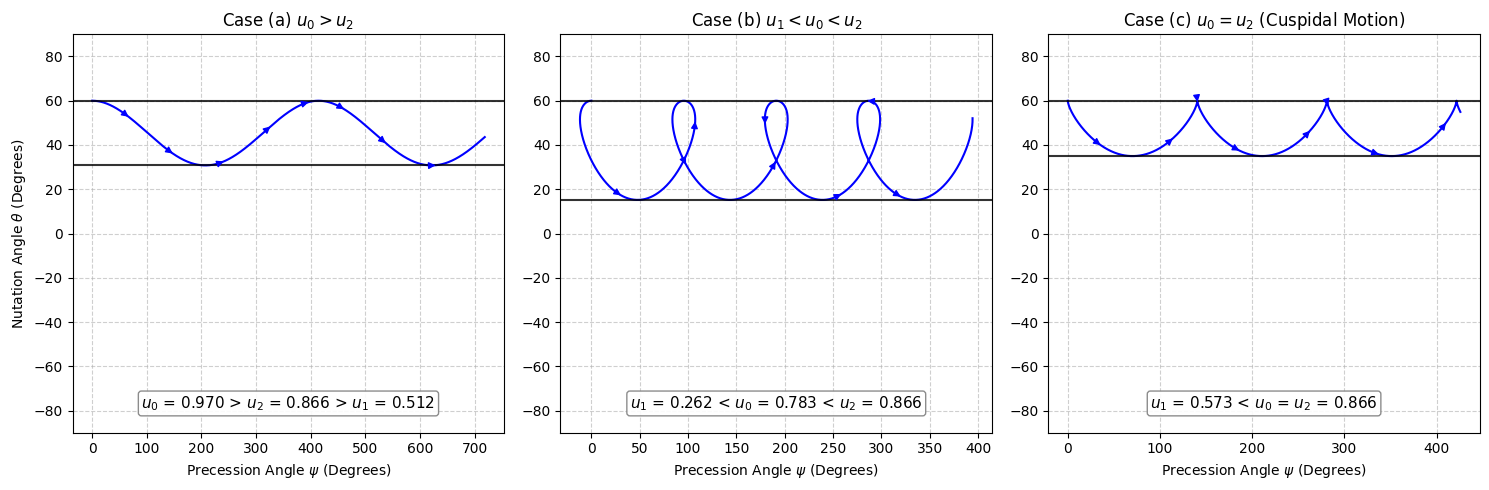

In [11]:
# Setup Solver
def top_odes(t, S, Omega, p_psi):
    
    m_val, g_val, l_val = 1.0, 9.81, 1.0
    Ia_val, It_val = 1.0, 5.0
    
    theta, psi, phi, theta_d = S
    
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)
    
    # Prevent Singularity
    if abs(cos_t) < 1e-6:
        cos_t = 1e-6 * np.sign(cos_t) if cos_t != 0 else 1e-6
        
    psi_d = (p_psi + Ia_val * Omega * sin_t) / (It_val * cos_t**2)
    phi_d = Omega + psi_d * sin_t
    
    theta_dd = (-m_val*g_val*l_val*cos_t + -It_val*psi_d**2*sin_t*cos_t + -Ia_val*Omega*psi_d*cos_t) / It_val
    
    return [theta_d, psi_d, phi_d, theta_dd]

def simulate_path(theta0, psi_d0, Omega, t_span=(0, 6)):
   
    Ia_val, It_val = 1.0, 5.0
    theta_d0 = 0.0
    
    # Calculate the conserved momentum
    p_psi = -Ia_val * Omega * np.sin(theta0) + It_val * psi_d0 * np.cos(theta0)**2  # Calculate the conserved momentum
    p_phi = Ia_val * Omega
    
    # Calculate critical parameter
    u_0 = -p_psi / p_phi
    
    S0 = [theta0, 0.0, 0.0, theta_d0]
    t_eval = np.linspace(t_span[0], t_span[1], 2000)
    sol = solve_ivp(top_odes, t_span, S0, args=(Omega, p_psi), 
                    method='LSODA', rtol=1e-9, atol=1e-11, t_eval=t_eval)
    
    return sol.t, sol.y[1], sol.y[0], u_0

# Setup and Solve 3 Cases in Figure 8-15
theta_start = np.radians(60)

t_A, psi_A, the_A, u0_A = simulate_path(theta0=theta_start, psi_d0 = -1.0, Omega = 12.0, t_span=(0, 10)) # Case (a): u_0 > u_2

t_B, psi_B, the_B, u0_B = simulate_path(theta0=theta_start, psi_d0 = 1.0, Omega = 15.0, t_span=(0, 10)) # Case (b): u_1 < u_0 < u_2

t_C, psi_C, the_C, u0_C = simulate_path(theta0=theta_start, psi_d0 = 0.0, Omega = 15.0, t_span=(0, 10)) # Case (c): u_0 = u_2

# Create 2D Plot
def add_path_arrows(ax, x, y, num_arrows=10):
    step = len(x) // (num_arrows + 1)
    for i in range(step, len(x) - step + 1, step):
        idx_prev = i - 15 
        ax.annotate('', xy=(x[i], y[i]), xytext=(x[idx_prev], y[idx_prev]),
                    arrowprops=dict(arrowstyle="-|>", color='blue', shrinkA=0, shrinkB=0))

def format_2d_plot1(ax, psi_data, the_data, u_0, title):
    x_deg = np.degrees(psi_data*-1)
    y_deg = np.degrees(the_data)
    
    # Calculate u1 (lower turning point) and u2 (upper turning point)
    u_data = np.sin(the_data)
    u_1 = np.min(u_data)
    u_2 = np.max(u_data)
    
    ax.plot(x_deg, y_deg, 'b-', linewidth=1.5)
    add_path_arrows(ax, x_deg, y_deg, num_arrows=8)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(r'Precession Angle $\psi$ (Degrees)')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    ax.axhline(np.max(y_deg), color='k', linestyle='-', alpha=0.8)
    ax.axhline(np.min(y_deg), color='k', linestyle='-', alpha=0.8)
          
    # Display the calculated u values inside the graph
    if u_0 > u_2:
        text_str = f"$u_0$ = {u_0:.3f} > $u_2$ = {u_2:.3f} > $u_1$ = {u_1:.3f}"

    if u_0 > u_1 and u_0 < u_2:
        text_str = f"$u_1$ = {u_1:.3f} < $u_0$ = {u_0:.3f} < $u_2$ = {u_2:.3f}"

    if u_0 == u_2 and u_0 > u_1:
        text_str = f"$u_1$ = {u_1:.3f} < $u_0$ = $u_2$ = {u_0:.3f}"
          
    ax.text(0.5, 0.05, text_str, transform=ax.transAxes, fontsize=11,
            verticalalignment='bottom', horizontalalignment='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    ax.set_ylim(-90, 90)

# Create 2D Plot same as Figure 8-15
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

format_2d_plot1(axes[0], psi_A, the_A, u0_A, r"Case (a) $u_0 > u_2$")
format_2d_plot1(axes[1], psi_B, the_B, u0_B, r"Case (b) $u_1 < u_0 < u_2$")
format_2d_plot1(axes[2], psi_C, the_C, u0_C, r"Case (c) $u_0 = u_2$ (Cuspidal Motion)")

axes[0].set_ylabel(r'Nutation Angle $\theta$ (Degrees)')
plt.tight_layout()
plt.show()

plot_3d_plotly(psi_A, the_A, "Case (a): u_0 > u_2")
plot_3d_plotly(psi_B, the_B, "Case (b): u_1 < u_0 < u_2")
plot_3d_plotly(psi_C, the_C, "Case (c): u_0 = u_2 (Cuspidal Motion)")

### **2. For cuspidal motion runs both cases as in page 426-427**

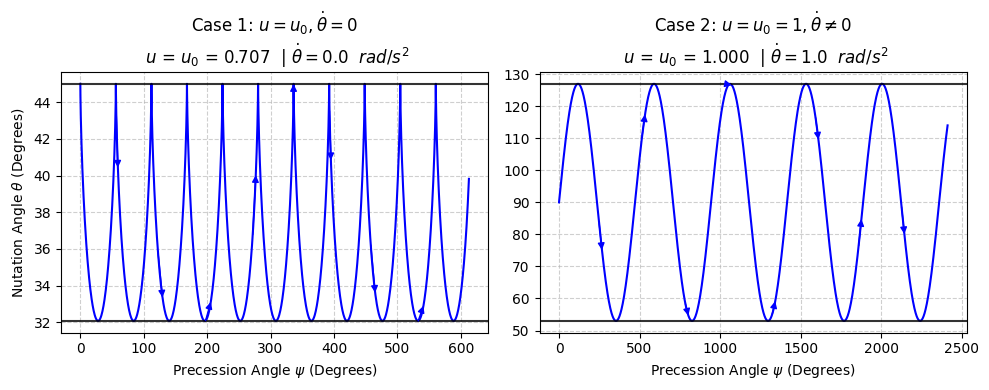

In [12]:
def simulate_path_cuspidal(theta0, psi_d0, theta_d0, Omega, t_span):
    Ia_val, It_val = 1.0, 5.0
    
    # Calculate the conserved momentum
    p_psi = -Ia_val * Omega * np.sin(theta0) + It_val * psi_d0 * np.cos(theta0)**2  # Calculate the conserved momentum
    p_phi = Ia_val * Omega
    
    # Calculate critical parameter
    u_0 = -p_psi / p_phi
    
    S0 = [theta0, 0.0, 0.0, theta_d0]
    t_eval = np.linspace(t_span[0], t_span[1], 2000)
    sol = solve_ivp(top_odes, t_span, S0, args=(Omega, p_psi), 
                    method='LSODA', rtol=1e-9, atol=1e-11, t_eval=t_eval)
    
    return sol.t, sol.y[1], sol.y[0], u_0


# Case 1: u = u_0 when theta_dot = 0
t_C1, psi_C1, the_C1, u0_C1 = simulate_path_cuspidal(
    theta0=np.radians(45), psi_d0=0.0, theta_d0=0.0, Omega=20.0, t_span=(0, 20)
)

# Case 2: theta_dot != 0 when u = u_0 = 1
t_C2, psi_C2, the_C2, u0_C2 = simulate_path_cuspidal(
    theta0=np.radians(90), psi_d0=0.0, theta_d0=1.0, Omega=20.0, t_span=(0, 20)
)


# Create 2D Plot
def add_path_arrows(ax, x, y, num_arrows=10):
    step = len(x) // (num_arrows + 1)
    for i in range(step, len(x) - step + 1, step):
        idx_prev = i - 15 
        ax.annotate('', xy=(x[i], y[i]), xytext=(x[idx_prev], y[idx_prev]),
                    arrowprops=dict(arrowstyle="-|>", color='blue', shrinkA=0, shrinkB=0))

def format_2d_plot2(ax, psi_data, the_data, u_0, theta_d0, title):
    x_deg = np.degrees(psi_data*-1)
    y_deg = np.degrees(the_data)
    
    # Calculate u1 (lower turning point) and u2 (upper turning point)
    u_data = np.sin(the_data)
    u = np.max(u_data)
    
    ax.plot(x_deg, y_deg, 'b-', linewidth=1.5)
    add_path_arrows(ax, x_deg, y_deg, num_arrows=8)
    
    ax.set_title(f"{title}\n $u$ = $u_0$ = {u:.3f}  | $\\dot\\theta = {theta_d0:.1f}$  $rad/s^2$", fontsize=12)
    ax.set_xlabel(r'Precession Angle $\psi$ (Degrees)')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    ax.axhline(np.max(y_deg), color='k', linestyle='-', alpha=0.8)
    ax.axhline(np.min(y_deg), color='k', linestyle='-', alpha=0.8)
            
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

format_2d_plot2(axes[0], psi_C1, the_C1, u0_C1,0, r"Case 1: $u = u_0,  \dot{\theta}=0$")
format_2d_plot2(axes[1], psi_C2, the_C2, u0_C2,1.0, r"Case 2: $u = u_0=1,  \dot{\theta} \neq 0$")

axes[0].set_ylabel(r'Nutation Angle $\theta$ (Degrees)')
plt.tight_layout()
plt.show()

plot_3d_plotly(psi_C1, the_C1, "Case 1: u=u_0 when theta_d=0")
plot_3d_plotly(psi_C2, the_C2, "Case 2: u=u_0=1 when theta_d!=0")

### **3. Run cases for stability of motion near the vertical (page 428-429)**

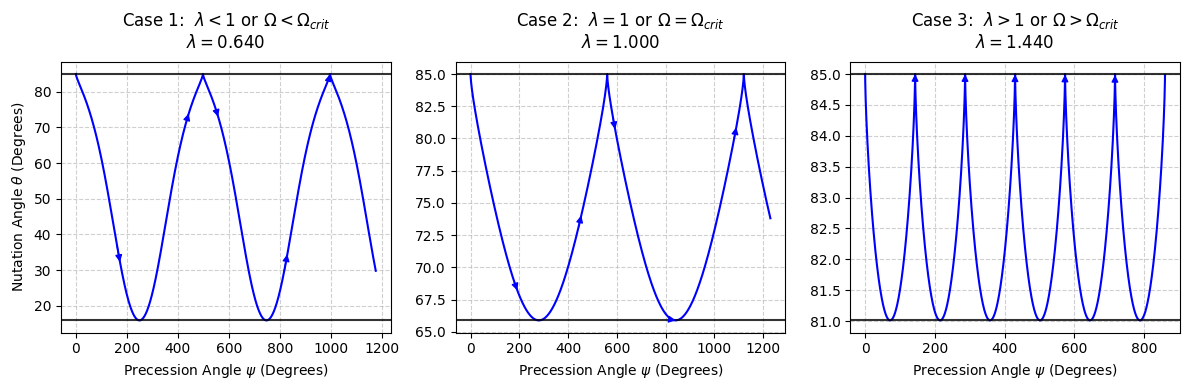

In [13]:
def simulate_stability(theta0, Omega, t_span=(0, 20)):
    m_val, g_val, l_val = 1.0, 9.81, 1.0
    Ia_val, It_val = 1.0, 5.0
    
    psi_d0 = 0.0
    theta_d0 = 0.0 
    
    # Calculate the conserved momentum
    p_psi = -Ia_val * Omega * np.sin(theta0) + It_val * psi_d0 * np.cos(theta0)**2
    
    # Calculate lambda
    lambda_val = (Ia_val**2 * Omega**2) / (4 * It_val * m_val * g_val * l_val)
    
    S0 = [theta0, 0.0, 0.0, theta_d0]
    t_eval = np.linspace(t_span[0], t_span[1], 2000)
    sol = solve_ivp(top_odes, t_span, S0, args=(Omega, p_psi), 
                    method='LSODA', rtol=1e-9, atol=1e-11, t_eval=t_eval)
    
    return sol.t, sol.y[1], sol.y[0], lambda_val

# Run the 3 Stability Cases
# Calculate the exact critical spin rate
m_v, g_v, l_v, Ia_v, It_v = 1.0, 9.81, 1.0, 1.0, 5.0
Omega_crit = np.sqrt(4 * It_v * m_v * g_v * l_v / (Ia_v**2))


theta_vert = np.radians(85.0)

# Case 1: Lamda < 1 or Omega < Omega_critical
t_U, psi_U, the_U, lam_U = simulate_stability(theta_vert, Omega_crit*0.8, t_span=(0, 20))

# Case 2: Lamda = 1 or Omega = Omega_critical
t_C, psi_C, the_C, lam_C = simulate_stability(theta_vert, Omega_crit*1.0, t_span=(0, 20))

# Case 3: Lamda > 1 or Omega > Omega_critical
t_S, psi_S, the_S, lam_S = simulate_stability(theta_vert, Omega_crit*1.2, t_span=(0, 20))


# Create 2D Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

def format_stability_plot(ax, psi_data, the_data, lam_val, title):
    x_deg = np.degrees(psi_data*-1)
    y_deg = np.degrees(the_data)
    
    ax.plot(x_deg, y_deg, 'b-', linewidth=1.5)
    add_path_arrows(ax, x_deg, y_deg, num_arrows=5)
    
    full_title = f"{title}\n$\\lambda={lam_val:.3f}$"
    ax.set_title(full_title, fontsize=12, pad=10)
    ax.set_xlabel(r'Precession Angle $\psi$ (Degrees)')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    ax.axhline(np.max(y_deg), color='k', linestyle='-', alpha=0.8)
    ax.axhline(np.min(y_deg), color='k', linestyle='-', alpha=0.8)
    
format_stability_plot(axes[0], psi_U, the_U, lam_U, r"Case 1:  $\lambda < 1$ or $\Omega < \Omega_{crit}$")
format_stability_plot(axes[1], psi_C, the_C, lam_C, r"Case 2:  $\lambda = 1$ or $\Omega = \Omega_{crit}$")
format_stability_plot(axes[2], psi_S, the_S, lam_S, r"Case 3:  $\lambda > 1$ or $\Omega > \Omega_{crit}$")

axes[0].set_ylabel(r'Nutation Angle $\theta$ (Degrees)')
plt.tight_layout()
plt.show()

# Create 3D Plot
plot_3d_plotly(psi_U, the_U, "Case 1: Lamda < 1 or Omega < Omega_critical")
plot_3d_plotly(psi_C, the_C, "Case 2: Lamda = 1 or Omega = Omega_critical")
plot_3d_plotly(psi_S, the_S, "Case 3: Lamda > 1 or Omega > Omega_critical")

### **4. Run cases for nutation and amplitude for the case of large spin (Page 429-430)**

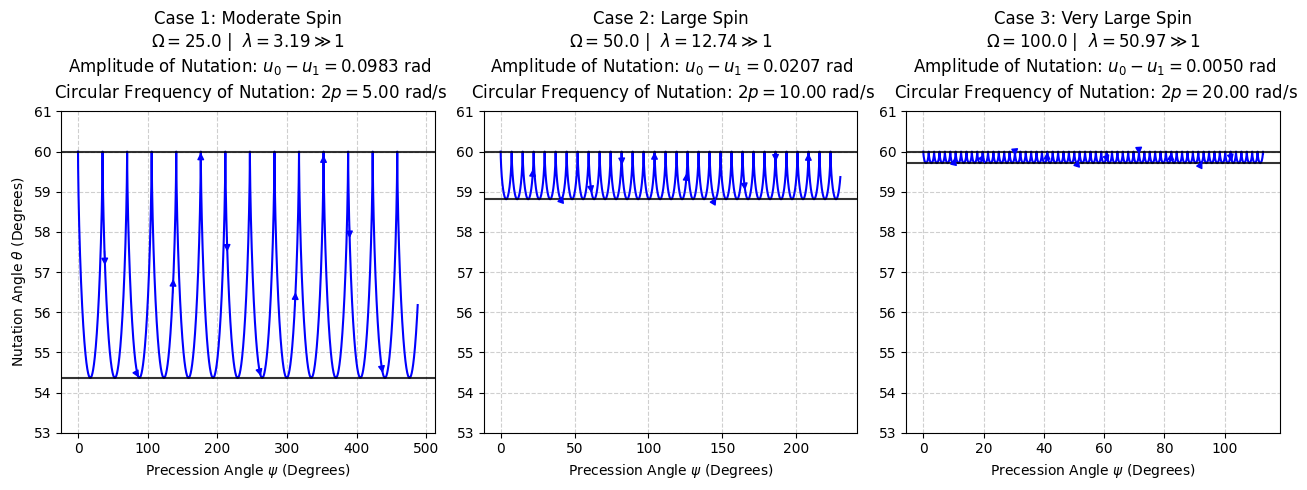

In [14]:
def simulate_fast_top(theta0, Omega, t_span=(0, 4)):
    m_val, g_val, l_val = 1.0, 9.81, 1.0
    Ia_val, It_val = 1.0, 5.0
    
    psi_d0 = 0.0
    theta_d0 = 0.0 
    
    # Calculate conserved momentum p_psi
    p_psi = -Ia_val * Omega * np.sin(theta0) + It_val * psi_d0 * np.cos(theta0)**2

    # Calculate lambda
    lambda_val = (Ia_val**2 * Omega**2) / (4 * It_val * m_val * g_val * l_val)
    
    S0 = [theta0, 0.0, 0.0, theta_d0]
    
    t_eval = np.linspace(t_span[0], t_span[1], 10000)
    sol = solve_ivp(top_odes, t_span, S0, args=(Omega, p_psi), 
                    method='LSODA', rtol=1e-10, atol=1e-12, t_eval=t_eval)
    
    return sol.t, sol.y[1], sol.y[0], lambda_val


# Run the 3 Large Spin Cases
theta_start = np.radians(60)

# Case 1: Moderate Spin (Omega = 25)
t_F1, psi_F1, the_F1, lamb_F1 = simulate_fast_top(theta_start, 25.0, t_span=(0, 20))

# Case 2: High Spin (Omega = 50)
t_F2, psi_F2, the_F2, lamb_F2 = simulate_fast_top(theta_start, 50.0, t_span=(0, 20))

# Case 3: Very Large Spin (Omega = 100)
t_F3, psi_F3, the_F3, lamb_F3 = simulate_fast_top(theta_start, 100.0, t_span=(0, 20))


# Create 2D Plot
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=False)

def format_fast_top_plot(ax, psi_data, the_data, Omega_val, lambda_val, title):
    x_deg = np.degrees(psi_data*-1)
    y_deg = np.degrees(the_data)
    
    # Calculate the Nutation Amplitude and Frequency
    amp_nutation = np.max(np.radians(y_deg)) - np.min(np.radians(y_deg))
    freq_nutation = Omega_val*Ia_val/It_val
    
    ax.plot(x_deg, y_deg, 'b-', linewidth=1.5)
    add_path_arrows(ax, x_deg, y_deg, num_arrows=10)
    
    full_title = f"{title}\n$\\Omega = {Omega_val}$ |  $\\lambda = {lambda_val:.2f} \\gg 1$\n Amplitude of Nutation: $u_0 - u_1 = {amp_nutation:.4f}$ rad \n Circular Frequency of Nutation: $2p = {freq_nutation:.2f}$ rad/s"
    ax.set_title(full_title, fontsize=12, pad=10)
    ax.set_xlabel(r'Precession Angle $\psi$ (Degrees)')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Draw the turning points
    ax.axhline(np.max(y_deg), color='k', linestyle='-', alpha=0.8)
    ax.axhline(np.min(y_deg), color='k', linestyle='-', alpha=0.8)
    
    ax.set_ylim(53, 61)
  
format_fast_top_plot(axes[0], psi_F1, the_F1, 25.0, lamb_F1, "Case 1: Moderate Spin")
format_fast_top_plot(axes[1], psi_F2, the_F2, 50.0, lamb_F2, "Case 2: Large Spin")
format_fast_top_plot(axes[2], psi_F3, the_F3, 100.0, lamb_F3, "Case 3: Very Large Spin")

axes[0].set_ylabel(r'Nutation Angle $\theta$ (Degrees)')
plt.tight_layout()
plt.show()

# Create 3D Plot
plot_3d_plotly(psi_F1, the_F1, "Case 1: Moderate Spin")
plot_3d_plotly(psi_F2, the_F2, "Case 2: Large Spin")
plot_3d_plotly(psi_F3, the_F3, "Case 3: Very Large Spin")

### **5. Run cases for precession with no nutation (Page 431-432)**

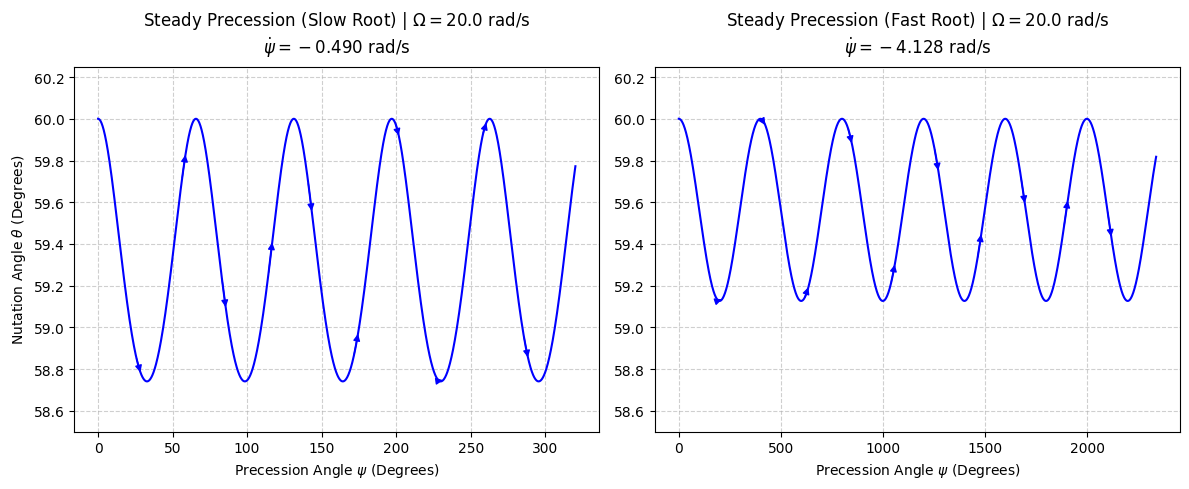

In [15]:
def simulate_steady_precession(theta0, Omega, speed_type='slow', t_span=(0, 4)):
    m_val, g_val, l_val = 1.0, 9.81, 1.0
    Ia_val, It_val = 1.0, 5.0
    
    # Calculate the coefficients for the quadratic equation of psi_dot
    b = Ia_val*Omega/It_val
    c = 2*m_val*g_val*l_val/It_val
    
    # Check the discriminant
    discriminant = 1- (c * np.sin(theta0) / b**2)
    if discriminant < 0:
        raise ValueError("Omega is too small")
    
    # Calculate the two valid roots
    psi_d_fast = -b * (1 + discriminant) / (2*np.sin(theta0))
    psi_d_slow = -b * (1 - discriminant) / (2*np.sin(theta0))
    
    # Select the requested speed
    psi_d0 = psi_d_fast if speed_type == 'fast' else psi_d_slow
    
    theta_d0 = 0.0  # Must have zero initial nutation velocity
    
    # Conserved momentum p_psi
    p_psi = -Ia_val * Omega * np.sin(theta0) + It_val * psi_d0 * np.cos(theta0)**2
    
    S0 = [theta0, 0.0, 0.0, theta_d0]
    
    t_eval = np.linspace(t_span[0], t_span[1], 2000)
    sol = solve_ivp(top_odes, t_span, S0, args=(Omega, p_psi), 
                    method='LSODA', rtol=1e-10, atol=1e-12, t_eval=t_eval)
    
    return sol.t, sol.y[1], sol.y[0], psi_d0


# Run 2 Steady Precession Cases
theta_start = np.radians(60)
Omega_steady = 20.0

# Case 1:  The slow precession rate
t_S1, psi_S1, the_S1, psid_slow = simulate_steady_precession(
    theta_start, Omega_steady, speed_type='slow', t_span=(0, 10)
)

# Case 2: The fast precession rate
t_S2, psi_S2, the_S2, psid_fast = simulate_steady_precession(
    theta_start, Omega_steady, speed_type='fast', t_span=(0, 10)
)

# Create 2D Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

def format_steady_plot(ax, psi_data, the_data, psi_dot_val, Omega_steady, title):
    x_deg = np.degrees(psi_data*-1)
    y_deg = np.degrees(the_data)
    
    ax.plot(x_deg, y_deg, 'b-', linewidth=1.5)
    add_path_arrows(ax, x_deg, y_deg, num_arrows=10)
    
    full_title = f"{title} | $\\Omega = {Omega_steady:.1f}$ rad/s\n$\\dot{{\\psi}} = {psi_dot_val:.3f}$ rad/s"
    ax.set_title(full_title, fontsize=12, pad=10)
    ax.set_xlabel(r'Precession Angle $\psi$ (Degrees)')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_ylim(58.5, 60.25)
    
format_steady_plot(axes[0], psi_S1, the_S1, psid_slow, Omega_steady, r"Steady Precession (Slow Root)")
format_steady_plot(axes[1], psi_S2, the_S2, psid_fast, Omega_steady, r"Steady Precession (Fast Root)")

axes[0].set_ylabel(r'Nutation Angle $\theta$ (Degrees)')
plt.tight_layout()
plt.show()

# Create 3D Plot
plot_3d_plotly(psi_S1, the_S1, "3D Path: Steady Precession (Slow)")
plot_3d_plotly(psi_S2, the_S2, "3D Path: Steady Precession (Fast)")

### **Export Trajectory to .txt file**

In [17]:
def export_trajectory(filename, t, psi, theta, Omega):
    """Calculates phi and exports the 3D trajectory data to a text file."""
    # 1. Calculate the sweeping speed (derivative of psi)
    psi_dot = np.gradient(psi, t)
    
    # 2. Calculate the spin speed (phi_dot)
    phi_dot = Omega + psi_dot * np.sin(theta)
    
    # 3. Integrate to get the actual spin angle (phi)
    phi = integrate.cumulative_trapezoid(phi_dot, t, initial=0)
    
    # 4. Pack and export
    export_data = np.column_stack((t, psi, theta, phi))
    np.savetxt(filename, export_data, header='t psi theta phi', comments='', fmt='%.6f')
    print(f"Successfully exported: {filename}")


# Example for Case 4.1
export_trajectory('Data/case_1_1.txt', t_A, psi_A, the_A, 12.0)
export_trajectory('Data/case_1_2.txt', t_B, psi_B, the_B, 15.0)
export_trajectory('Data/case_1_3.txt', t_C, psi_C, the_C, 15.0)

# Export Case 2
export_trajectory('Data/case_2_1.txt', t_C1, psi_C1, the_C1, 20.0)
export_trajectory('Data/case_2_1.txt', t_C1, psi_C1, the_C1, 20.0)

# Example for Case 4.3 (Stability)
export_trajectory('Data/case_3_1.txt', t_U, psi_U, the_U, Omega_crit*0.8)
export_trajectory('Data/case_3_2.txt', t_C, psi_C, the_C, Omega_crit*1)
export_trajectory('Data/case_3_3.txt', t_S, psi_S, the_S, Omega_crit*1.2)

# Example for Case 4.5 (Steady Precession)
export_trajectory('Data/case_4_1.txt', t_F1, psi_F1, the_F1, 25.0)
export_trajectory('Data/case_4_2.txt', t_F2, psi_F2, the_F2, 50.0)
export_trajectory('Data/case_4_3.txt', t_F3, psi_F3, the_F3, 100.0)

# Example for Case 4.5 (Steady Precession)
export_trajectory('Data/case_5_1.txt', t_S1, psi_S1, the_S1, 20.0)
export_trajectory('Data/case_5_2.txt', t_S2, psi_S2, the_S2, 20.0)

Successfully exported: Data/case_1_1.txt
Successfully exported: Data/case_1_2.txt
Successfully exported: Data/case_1_3.txt
Successfully exported: Data/case_2_1.txt
Successfully exported: Data/case_2_1.txt
Successfully exported: Data/case_3_1.txt
Successfully exported: Data/case_3_2.txt
Successfully exported: Data/case_3_3.txt
Successfully exported: Data/case_4_1.txt
Successfully exported: Data/case_4_2.txt
Successfully exported: Data/case_4_3.txt
Successfully exported: Data/case_5_1.txt
Successfully exported: Data/case_5_2.txt
